In [3]:
# =============================================================================
# INTERRUPTED WEIGHTED SYNTHETIC CONTROL (IWSC) IN PYTHON
# Problem: Measuring the causal impact of a city-wide electric scooter policy
# on traffic congestion index across cities
#

In [4]:
# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [51]:
# =============================================================================
# PROBLEM STATEMENT
# =============================================================================
# A regional transportation authority introduced a subsidized electric scooter
# program in City A starting in January 2022. You are a Data Scientist
# asked to evaluate: Did the scooter program CAUSALLY reduce the city's
# Traffic Congestion Index (TCI, scale 0-100)?
#
# You have monthly TCI data from Jan 2019 to Dec 2023 for City A (treated)
# and 8 donor cities (controls) that never adopted the program.
#
# Challenge: Standard DiD fails because cities are not parallel-trend
# compatible. Synthetic Control builds a weighted combination of donor cities
# that best matches City A pre-intervention, then we compare post-intervention.
#
# IWSC adds: time-varying weights (interrupted weights) to handle structural
# breaks or donor instability across pre-period subwindows.
# =============================================================================

# What is Interrrupted weights?
# In IWSC you split the pre-period into say 3 windows, 
# solve the optimization separately in each window (getting 3 different weight vectors), 
# then average them. 
# So if City B was very predictive of City A in 2019 but less so in 2021, the window weights capture that shift. 
# The final averaged weight is more robust than one global fit.

In [8]:
# =============================================================================
# SECTION 1: DATA GENERATION
# =============================================================================

In [9]:
def generate_time_index(start="2019-01", end="2023-12", freq="MS"):
    """
    Creates a sequence of monthly timestamps from start to end.
    'MS' means Month Start frequency in pandas.
    Returns a DatetimeIndex object.
    """
    return pd.date_range(start=start, end=end, freq=freq)

In [10]:
def make_donor_cities(time_index, n_donors=8, seed=42):
    """
    Simulates monthly Traffic Congestion Index (TCI) for 8 donor cities.
    Each city gets:
      - A baseline level (50-80)
      - A slow upward drift over time (cities get more congested)
      - A seasonal sine wave (rush seasons)
      - Random noise

    Returns a DataFrame where each column is one donor city's TCI over time.
    """
    rng = np.random.default_rng(seed)
    n = len(time_index)
    t = np.arange(n)

    donors = {}
    baselines = [65, 72, 58, 70, 62, 75, 68, 55]
    drifts    = [0.05, 0.03, 0.07, 0.02, 0.06, 0.04, 0.03, 0.08]
    seasons   = [3.0, 2.5, 4.0, 1.5, 3.5, 2.0, 2.8, 3.2]
    noises    = [1.2, 1.5, 1.0, 1.8, 1.3, 1.6, 1.1, 1.4]

    for i in range(n_donors):
        city_tci = (
            baselines[i]
            + drifts[i] * t
            + seasons[i] * np.sin(2 * np.pi * t / 12)
            + rng.normal(0, noises[i], n)
        )
        donors[f"City_{chr(66+i)}"] = np.clip(city_tci, 0, 100)

    return pd.DataFrame(donors, index=time_index)

In [12]:
def make_treated_city_with_impact(time_index, donor_df, intervention_date="2022-01-01", seed=99):
    """
    DATASET 1: City A WITH a real causal impact from the scooter program.

    Pre-intervention: City A is a weighted blend of donors + noise.
      This ensures synthetic control can reconstruct City A well pre-policy.

    Post-intervention: A gradual reduction (ramp-down effect) kicks in,
      simulating the scooter program reducing congestion over time.
      The effect grows from 0 to -8 TCI points over 12 months, then stabilizes.

    Returns a pandas Series of City A's TCI.
    """
    rng = np.random.default_rng(seed)
    n = len(time_index)
    t = np.arange(n)
    cutoff = time_index.get_loc(pd.Timestamp(intervention_date))

    # True underlying weights that generated City A from donors
    true_weights = np.array([0.30, 0.20, 0.15, 0.10, 0.10, 0.07, 0.05, 0.03])
    donor_matrix = donor_df.values  # shape: (n_time, n_donors)

    city_a = donor_matrix @ true_weights  # weighted combination of donors

    # Add City A specific trend + noise (makes it realistic, not a perfect clone)
    city_a += 0.04 * t + rng.normal(0, 1.0, n) - 2.0

    # Post-intervention: ramp down effect (treatment effect)
    post_len = n - cutoff
    ramp = np.zeros(n)
    ramp_effect = np.linspace(0, -8, min(12, post_len))  # gradual reduction
    stable_effect = np.full(max(0, post_len - 12), -8.0)  # stabilizes at -8
    ramp[cutoff:] = np.concatenate([ramp_effect, stable_effect])

    city_a += ramp
    return pd.Series(np.clip(city_a, 0, 100), index=time_index, name="City_A")

In [13]:
def make_treated_city_no_impact(time_index, donor_df, intervention_date="2022-01-01", seed=77):
    """
    DATASET 2: City A WITHOUT any real causal impact (null case).

    The city adopted the scooter program on paper, but it had zero effect
    on congestion. City A just follows its natural trajectory.

    This is used to verify that our method correctly finds NO effect
    when none exists -- a key validity check for any causal inference method.
    """
    rng = np.random.default_rng(seed)
    n = len(time_index)
    t = np.arange(n)

    true_weights = np.array([0.30, 0.20, 0.15, 0.10, 0.10, 0.07, 0.05, 0.03])
    donor_matrix = donor_df.values

    city_a = donor_matrix @ true_weights
    city_a += 0.04 * t + rng.normal(0, 1.0, n) - 2.0

    # No post-intervention effect added -- city follows natural path
    return pd.Series(np.clip(city_a, 0, 100), index=time_index, name="City_A")



In [15]:
# =============================================================================
# SECTION 2: SYNTHETIC CONTROL CORE FUNCTIONS
# =============================================================================

In [18]:
def split_preperiod_windows(time_index, intervention_date, n_windows=3):
    """
    IWSC Key Idea: Instead of fitting weights on the entire pre-period at once,
    we split the pre-period into equal sub-windows.

    Why? Donor cities may have different structural relationships with the
    treated city at different points in time. Using sub-windows lets us
    capture time-varying relevance of each donor.

    Returns: list of boolean masks, one per window, each covering 1/n_windows
    of the pre-intervention period.
    """
    cutoff_idx = time_index.get_loc(pd.Timestamp(intervention_date))
    pre_indices = np.arange(cutoff_idx)
    windows = np.array_split(pre_indices, n_windows)
    masks = []
    for w in windows:
        mask = np.zeros(len(time_index), dtype=bool)
        mask[w] = True
        masks.append(mask)
    return masks

In [21]:
def fit_synthetic_control_weights(treated_pre, donor_pre):
    """
    Core optimization function. Finds the best set of non-negative weights
    that sum to 1, such that the weighted donor combination most closely
    matches the treated city in the pre-period.

    This is a constrained quadratic minimization:
      minimize  ||treated - donors @ weights||^2
      subject to  weights >= 0, sum(weights) = 1

    Uses scipy.optimize.minimize with SLSQP solver (Sequential Least Squares).

    Returns: 1D array of weights (one per donor city).
    """
    n_donors = donor_pre.shape[1]
    w0 = np.ones(n_donors) / n_donors  # equal weights as starting point

    def objective(w):
        # Sum of squared differences between treated and synthetic
        synthetic = donor_pre @ w
        return np.sum((treated_pre - synthetic) ** 2)

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n_donors

    result = minimize(objective, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"ftol": 1e-10, "maxiter": 1000})
    return result.x

In [22]:
def compute_iwsc_weights(treated_series, donor_df, time_index,
                          intervention_date, n_windows=3):
    """
    INTERRUPTED WEIGHTED SYNTHETIC CONTROL weight computation.

    Steps:
      1. Split the pre-period into n_windows sub-windows.
      2. For each sub-window, solve the synthetic control optimization
         (find donor weights that best match treated city in that window).
      3. Average the per-window weights across all windows.
         This averaging is the "interrupted" part -- it blends weights
         from different temporal regimes, making the synthetic control
         more robust to structural breaks in donor relationships.

    Returns: final 1D weight array (one weight per donor).
    """
    cutoff_idx = time_index.get_loc(pd.Timestamp(intervention_date))
    pre_mask_all = np.arange(cutoff_idx)

    donor_matrix = donor_df.values
    treated_vals = treated_series.values

    window_masks = split_preperiod_windows(time_index, intervention_date, n_windows)

    all_weights = []
    for mask in window_masks:
        # Extract data for this sub-window only
        donor_window  = donor_matrix[mask]
        treated_window = treated_vals[mask]
        w = fit_synthetic_control_weights(treated_window, donor_window)
        all_weights.append(w)

    # Average weights across windows (the "interrupted" aggregation)
    iwsc_weights = np.mean(all_weights, axis=0)

    # Renormalize so weights still sum to 1
    iwsc_weights /= iwsc_weights.sum()
    return iwsc_weights, all_weights  # also return per-window weights for inspection

In [27]:
def build_synthetic_series(donor_df, weights):
    """
    Given a full donor DataFrame and a weight vector,
    computes the synthetic control series for ALL time periods
    (pre and post intervention).

    synthetic[t] = sum over donors of (weight_i * donor_i[t])

    Returns a pandas Series indexed by time.
    """
    synthetic_vals = donor_df.values @ weights
    return pd.Series(synthetic_vals, index=donor_df.index, name="Synthetic_City_A")

In [28]:
def compute_treatment_effect(treated_series, synthetic_series, intervention_date):
    """
    Computes the estimated causal effect at each post-intervention time point.

    effect[t] = treated[t] - synthetic[t]

    If the program had NO effect, this should be close to zero.
    If the program REDUCED congestion, this should be negative.

    Also computes the pre-period fit (residuals) to assess synthetic control quality.

    Returns: dict with 'pre_residuals', 'post_effects', 'att' (average treatment effect)
    """
    cutoff = pd.Timestamp(intervention_date)
    pre_treated  = treated_series[treated_series.index < cutoff]
    post_treated = treated_series[treated_series.index >= cutoff]

    pre_synth  = synthetic_series[synthetic_series.index < cutoff]
    post_synth = synthetic_series[synthetic_series.index >= cutoff]

    pre_residuals  = pre_treated.values  - pre_synth.values
    post_effects   = post_treated.values - post_synth.values
    att = np.mean(post_effects)  # Average Treatment Effect on the Treated

    return {
        "pre_residuals": pre_residuals,
        "post_effects":  post_effects,
        "att":           att,
        "post_dates":    post_treated.index,
        "pre_dates":     pre_treated.index,
    }

In [29]:
# =============================================================================
# SECTION 3: PLACEBO / PERMUTATION INFERENCE
# =============================================================================

In [30]:
def run_placebo_tests(treated_series, donor_df, time_index,
                       intervention_date, n_windows=3):
    """
    Placebo / Permutation Test -- the gold standard for synthetic control inference.

    Idea: Run the EXACT same IWSC procedure, but pretend EACH DONOR is the
    treated unit (while all other donors are the control pool).

    If the real effect (City A's post-gap) is large compared to the
    distribution of placebo gaps, we have statistical evidence of a true effect.

    This is the synthetic control equivalent of computing a p-value:
      p = (number of placebo ATTs as extreme as real ATT) / (total placebos)

    Returns:
      - placebo_effects: list of post-period effect arrays (one per placebo)
      - placebo_atts:    list of ATT scalars (one per placebo)
    """
    donor_names = donor_df.columns.tolist()
    placebo_effects = []
    placebo_atts    = []

    for leave_out in donor_names:
        # This donor becomes the "fake treated unit"
        fake_treated = donor_df[leave_out]
        # Remaining donors form the pool
        fake_donors  = donor_df.drop(columns=[leave_out])

        try:
            w, _ = compute_iwsc_weights(fake_treated, fake_donors,
                                         time_index, intervention_date, n_windows)
            fake_synth = build_synthetic_series(fake_donors, w)
            effects    = compute_treatment_effect(fake_treated, fake_synth, intervention_date)

            # Only keep placebos with decent pre-period fit (MSPE filter)
            mspe = np.mean(effects["pre_residuals"] ** 2)
            if mspe < 20:  # filter out bad fits -- they add noise, not signal
                placebo_effects.append(effects["post_effects"])
                placebo_atts.append(effects["att"])
        except Exception:
            pass

    return placebo_effects, placebo_atts


In [31]:
# =============================================================================
# SECTION 4: FULL ANALYSIS PIPELINE
# =============================================================================

In [32]:
def run_full_analysis(label, treated_series, donor_df, time_index,
                       intervention_date="2022-01-01", n_windows=3):
    """
    Master function that ties everything together:
      1. Fit IWSC weights
      2. Build synthetic series
      3. Compute treatment effects
      4. Run placebo tests
      5. Compute p-value

    Returns a results dictionary with everything needed for plotting and reporting.
    """
    print(f"\n{'='*60}")
    print(f"  ANALYSIS: {label}")
    print(f"{'='*60}")

    # Step 1: Fit IWSC weights
    weights, window_weights = compute_iwsc_weights(
        treated_series, donor_df, time_index, intervention_date, n_windows
    )
    print("\nFinal IWSC Donor Weights:")
    for city, w in zip(donor_df.columns, weights):
        print(f"  {city}: {w:.4f}")

    # Step 2: Build synthetic control series
    synthetic = build_synthetic_series(donor_df, weights)

    # Step 3: Compute treatment effects
    effects = compute_treatment_effect(treated_series, synthetic, intervention_date)
    att = effects["att"]
    pre_mspe = np.mean(effects["pre_residuals"] ** 2)
    print(f"\nPre-period MSPE (fit quality, lower is better): {pre_mspe:.4f}")
    print(f"Average Treatment Effect on Treated (ATT):      {att:.4f} TCI points")

    # Step 4: Placebo tests
    print("\nRunning placebo tests (this applies IWSC to each donor as fake treated)...")
    placebo_effects, placebo_atts = run_placebo_tests(
        treated_series, donor_df, time_index, intervention_date, n_windows
    )

    # Step 5: Permutation p-value
    # p = fraction of placebos with ATT at least as extreme as real ATT
    extreme_count = np.sum(np.array(placebo_atts) <= att)
    p_value = extreme_count / len(placebo_atts)
    print(f"Placebo ATTs range: [{min(placebo_atts):.2f}, {max(placebo_atts):.2f}]")
    print(f"Permutation p-value: {p_value:.4f}")

    return {
        "label":            label,
        "treated":          treated_series,
        "synthetic":        synthetic,
        "effects":          effects,
        "att":              att,
        "pre_mspe":         pre_mspe,
        "weights":          weights,
        "window_weights":   window_weights,
        "placebo_effects":  placebo_effects,
        "placebo_atts":     placebo_atts,
        "p_value":          p_value,
        "intervention_date": pd.Timestamp(intervention_date),
    }

In [34]:
# =============================================================================
# SECTION 5: VISUALIZATION
# =============================================================================

In [35]:
def plot_full_results(res, donor_df):
    """
    Creates a comprehensive 6-panel diagnostic figure for one IWSC analysis.

    Panel layout:
      [1] Main SC plot: Treated vs Synthetic over full time
      [2] Treatment effect gap (post-intervention only)
      [3] Donor weight bar chart (final IWSC weights)
      [4] Pre-period residuals (fit quality check)
      [5] Placebo distribution vs real ATT
      [6] Per-window weight heatmap (the "interrupted" part)
    """
    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor("#0f1117")

    gs = gridspec.GridSpec(3, 3, figure=fig,
                           hspace=0.45, wspace=0.35,
                           left=0.06, right=0.97,
                           top=0.92, bottom=0.06)

    color_treated  = "#00d4ff"
    color_synth    = "#ff6b35"
    color_effect   = "#a8ff78"
    color_placebo  = "#888888"
    color_zero     = "#ffffff"
    ax_bg          = "#1a1d27"

    def style_ax(ax, title):
        # Applies dark background and white text styling to each panel
        ax.set_facecolor(ax_bg)
        ax.tick_params(colors="white", labelsize=9)
        ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=8)
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")

    iv_date = res["intervention_date"]

    # ------------------------------------------------------------------
    # PANEL 1 (spans 2 columns): Treated vs Synthetic full time series
    # This is the signature synthetic control plot.
    # The two lines should overlap closely in the pre-period (good fit),
    # then diverge post-intervention if there's a real effect.
    # ------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(res["treated"].index, res["treated"].values,
             color=color_treated, lw=2.2, label="City A (Treated)")
    ax1.plot(res["synthetic"].index, res["synthetic"].values,
             color=color_synth, lw=2.2, ls="--", label="Synthetic City A")
    ax1.axvline(iv_date, color="yellow", lw=1.5, ls=":", alpha=0.9)
    ax1.text(iv_date, ax1.get_ylim()[1] * 0.98, " Policy\n Start",
             color="yellow", fontsize=8, va="top")
    ax1.set_ylabel("Traffic Congestion Index")
    ax1.legend(facecolor="#222", labelcolor="white", fontsize=9)
    style_ax(ax1, f"[{res['label']}] Treated vs Synthetic Control")

    # ------------------------------------------------------------------
    # PANEL 2: Post-intervention gap (treatment effect over time)
    # If bars are consistently below zero, the policy reduced congestion.
    # If bars hover around zero, there is no detectable causal effect.
    # ------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[0, 2])
    post_dates   = res["effects"]["post_dates"]
    post_effects = res["effects"]["post_effects"]
    colors_bar   = [color_effect if v < 0 else "#ff4444" for v in post_effects]
    ax2.bar(post_dates, post_effects, color=colors_bar, alpha=0.85, width=25)
    ax2.axhline(0, color=color_zero, lw=1, ls="--")
    ax2.axhline(res["att"], color="#ffd700", lw=1.5, ls="-.",
                label=f"ATT = {res['att']:.2f}")
    ax2.set_ylabel("Effect (TCI points)")
    ax2.legend(facecolor="#222", labelcolor="white", fontsize=8)
    style_ax(ax2, "Post-Intervention Gap")

    # ------------------------------------------------------------------
    # PANEL 3: Donor weight bar chart
    # Shows how much each donor city contributes to the synthetic control.
    # Heavier donors = more similar to City A in the pre-period.
    # ------------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 0])
    cities  = donor_df.columns.tolist()
    weights = res["weights"]
    bar_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(cities)))
    ax3.barh(cities, weights, color=bar_colors, edgecolor="#333")
    ax3.set_xlabel("Weight")
    ax3.axvline(1/len(cities), color="white", lw=1, ls="--", alpha=0.5,
                label="Equal weight")
    ax3.legend(facecolor="#222", labelcolor="white", fontsize=8)
    style_ax(ax3, "IWSC Donor Weights")

    # ------------------------------------------------------------------
    # PANEL 4: Pre-period residuals (treated minus synthetic)
    # Should be small and centered at zero -- confirms good pre-period fit.
    # Large systematic residuals = poor synthetic control match.
    # ------------------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1])
    pre_dates = res["effects"]["pre_dates"]
    pre_res   = res["effects"]["pre_residuals"]
    ax4.plot(pre_dates, pre_res, color="#bb86fc", lw=1.5)
    ax4.fill_between(pre_dates, pre_res, 0, alpha=0.3, color="#bb86fc")
    ax4.axhline(0, color=color_zero, lw=1, ls="--")
    ax4.set_ylabel("Residual (TCI)")
    ax4.text(0.05, 0.92, f"MSPE: {res['pre_mspe']:.3f}",
             transform=ax4.transAxes, color="white", fontsize=9)
    style_ax(ax4, "Pre-Period Fit Residuals")

    # ------------------------------------------------------------------
    # PANEL 5: Placebo distribution histogram
    # The gray bars show ATTs from all placebo (fake treated) runs.
    # The yellow vertical line = real City A ATT.
    # If yellow line is in the far left tail, effect is statistically rare.
    # The p-value annotation tells you how often placebos beat real effect.
    # ------------------------------------------------------------------
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.hist(res["placebo_atts"], bins=12, color=color_placebo,
             edgecolor="#333", alpha=0.8, label="Placebo ATTs")
    ax5.axvline(res["att"], color="#ffd700", lw=2.5, ls="-",
                label=f"Real ATT = {res['att']:.2f}")
    ax5.set_xlabel("ATT (TCI points)")
    ax5.set_ylabel("Count")
    ax5.legend(facecolor="#222", labelcolor="white", fontsize=8)
    ax5.text(0.05, 0.85, f"p = {res['p_value']:.3f}",
             transform=ax5.transAxes, color="#ffd700",
             fontsize=11, fontweight="bold")
    style_ax(ax5, "Permutation Inference")

    # ------------------------------------------------------------------
    # PANEL 6: Per-window weight heatmap
    # This is the "interrupted" part of IWSC.
    # Each row = one sub-window of the pre-period.
    # Each column = one donor city.
    # Colors show how much weight each donor got in each time window.
    # Variance across rows = structural breaks in donor relationships.
    # ------------------------------------------------------------------
    ax6 = fig.add_subplot(gs[2, :])
    window_w_matrix = np.array(res["window_weights"])
    im = ax6.imshow(window_w_matrix, aspect="auto", cmap="YlOrRd",
                    vmin=0, vmax=window_w_matrix.max())
    ax6.set_xticks(range(len(cities)))
    ax6.set_xticklabels(cities, color="white", fontsize=9)
    ax6.set_yticks(range(len(window_w_matrix)))
    ax6.set_yticklabels([f"Window {i+1}" for i in range(len(window_w_matrix))],
                        color="white", fontsize=9)
    plt.colorbar(im, ax=ax6, label="Weight")
    ax6.set_xlabel("Donor City", color="white")
    style_ax(ax6, "Per-Window Donor Weights (The 'Interrupted' Component)")

    fig.suptitle(f"IWSC Full Diagnostic: {res['label']}",
                 color="white", fontsize=15, fontweight="bold", y=0.98)
    plt.show()

In [48]:
def plot_side_by_side_comparison(res1, res2):
    """
    Creates a clean 2-panel side-by-side comparison of the two datasets.

    Left panel: Case WITH real causal impact.
    Right panel: Null case (no impact).

    Both show the treated vs synthetic series and the post-intervention gap.
    This makes it immediately obvious when a method correctly detects
    an effect vs correctly reports null.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.patch.set_facecolor("#0f1117")

    for ax, res in zip(axes, [res1, res2]):
        ax.set_facecolor("#1a1d27")
        iv = res["intervention_date"]

        ax.plot(res["treated"].index, res["treated"].values,
                color="#00d4ff", lw=2.2, label="City A (Treated)")
        ax.plot(res["synthetic"].index, res["synthetic"].values,
                color="#ff6b35", lw=2.2, ls="--", label="Synthetic City A")

        # Shade the post-period gap to make the effect (or lack of it) visible
        post_dates   = res["effects"]["post_dates"]
        post_treated = res["treated"][post_dates].values
        post_synth   = res["synthetic"][post_dates].values
        shade_color  = "#a8ff7844" if res["att"] < -1 else "#ff444444"
        ax.fill_between(post_dates, post_treated, post_synth,
                        alpha=0.35, color=shade_color,
                        label=f"Gap (ATT={res['att']:.2f})")

        ax.axvline(iv, color="yellow", lw=1.5, ls=":", alpha=0.9)
        ax.set_ylabel("Traffic Congestion Index", color="white")
        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")
        ax.set_title(res["label"], color="white", fontsize=12, fontweight="bold")
        ax.legend(facecolor="#222", labelcolor="white", fontsize=9)

        verdict = "EFFECT DETECTED" if res["p_value"] < 0.1 else "NO EFFECT"
        vc = "#a8ff78" if res["p_value"] < 0.1 else "#ff4444"
        ax.text(0.98, 0.04, f"{verdict}  p={res['p_value']:.3f}",
                transform=ax.transAxes, color=vc,
                fontsize=10, fontweight="bold", ha="right",
                bbox=dict(facecolor="#0f1117", edgecolor=vc, boxstyle="round,pad=0.3"))

    fig.suptitle("IWSC Comparison: Real Impact vs Null Case",
                 color="white", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [36]:
def plot_donor_data_overview(donor_df, treated_impact, treated_null, intervention_date):
    """
    Overview chart showing all donor cities and both versions of City A.
    Donors are shown in muted gray so City A stands out.
    Helps verify that City A is plausibly within the donor distribution
    (a requirement for synthetic control validity).
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
    fig.patch.set_facecolor("#0f1117")
    iv = pd.Timestamp(intervention_date)

    for ax, treated, title in zip(
        axes,
        [treated_impact, treated_null],
        ["Dataset 1: With Causal Impact", "Dataset 2: Null Case (No Impact)"]
    ):
        ax.set_facecolor("#1a1d27")
        for col in donor_df.columns:
            ax.plot(donor_df.index, donor_df[col], color="#555", lw=1, alpha=0.6)
        ax.plot(treated.index, treated.values,
                color="#00d4ff", lw=2.5, label="City A (Treated)", zorder=5)
        ax.axvline(iv, color="yellow", lw=1.5, ls=":", alpha=0.9)
        ax.set_ylabel("TCI", color="white")
        ax.set_title(title, color="white", fontsize=11, fontweight="bold")
        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")
        ax.legend(facecolor="#222", labelcolor="white")

    fig.suptitle("Raw Data: City A vs Donor Pool (gray = donors)",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    

In [37]:
# =============================================================================
# SECTION 6: MAIN EXECUTION
# =============================================================================

In [39]:
# -------------------------------------------------------------------------
# Step A: Build time axis and donor cities
# -------------------------------------------------------------------------
time_index = generate_time_index("2019-01", "2023-12")
donor_df   = make_donor_cities(time_index)
INTERVENTION = "2022-01-01"

In [40]:
# -------------------------------------------------------------------------
# Step B: Generate both versions of City A
# -------------------------------------------------------------------------
treated_impact = make_treated_city_with_impact(time_index, donor_df, INTERVENTION)
treated_null   = make_treated_city_no_impact(time_index, donor_df, INTERVENTION)

In [41]:
treated_impact.head()

2019-01-01    63.943839
2019-02-01    64.553171
2019-03-01    66.989895
2019-04-01    68.490398
2019-05-01    65.117893
Freq: MS, Name: City_A, dtype: float64

In [42]:
treated_null.head()

2019-01-01    64.289115
2019-02-01    64.446752
2019-03-01    69.593840
2019-04-01    66.195622
2019-05-01    67.536400
Freq: MS, Name: City_A, dtype: float64

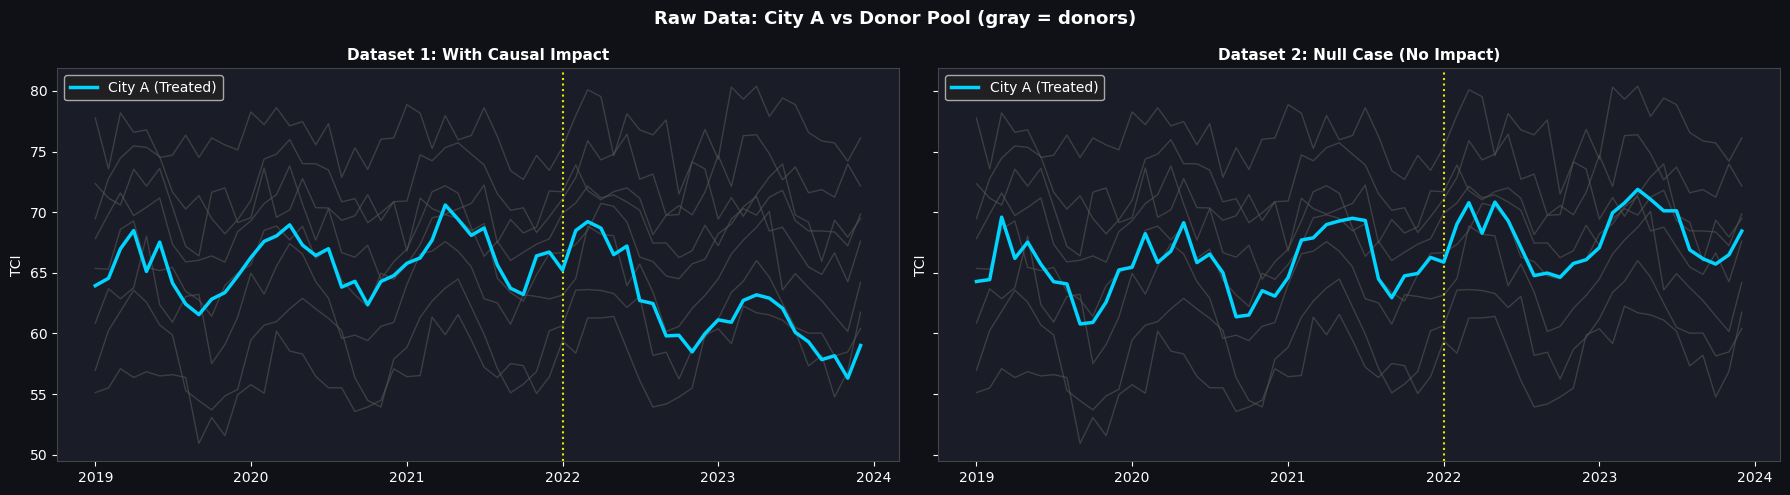

In [53]:
# -------------------------------------------------------------------------
# Step C: Overview chart -- see the raw data before any modeling
# -------------------------------------------------------------------------
plot_donor_data_overview(donor_df, treated_impact, treated_null, INTERVENTION)

In [ ]:
#   WHAT TO CHECK:
#   City A should sit within the band of donor cities -- not way above or
#   below all of them. If City A is a total outlier, synthetic control
#   cannot build a credible counterfactual from this donor pool.
#   This is the first sanity check before doing any modeling.

In [ ]:
#   WHAT TO LOOK FOR: In the pre-period (left of yellow line), the two lines
    #   should be close together -- that means our synthetic is a good match.
    #   In the post-period (right of yellow line), if blue drops below orange,
    #   the policy reduced congestion. The bigger the gap, the stronger the effect.
    #


  ANALYSIS: Dataset 1 - With Causal Impact

Final IWSC Donor Weights:
  City_B: 0.4291
  City_C: 0.0558
  City_D: 0.0622
  City_E: 0.0883
  City_F: 0.0479
  City_G: 0.0743
  City_H: 0.0986
  City_I: 0.1439

Pre-period MSPE (fit quality, lower is better): 0.7853
Average Treatment Effect on Treated (ATT):      -5.0018 TCI points

Running placebo tests (this applies IWSC to each donor as fake treated)...
Placebo ATTs range: [-2.53, 3.93]
Permutation p-value: 0.0000


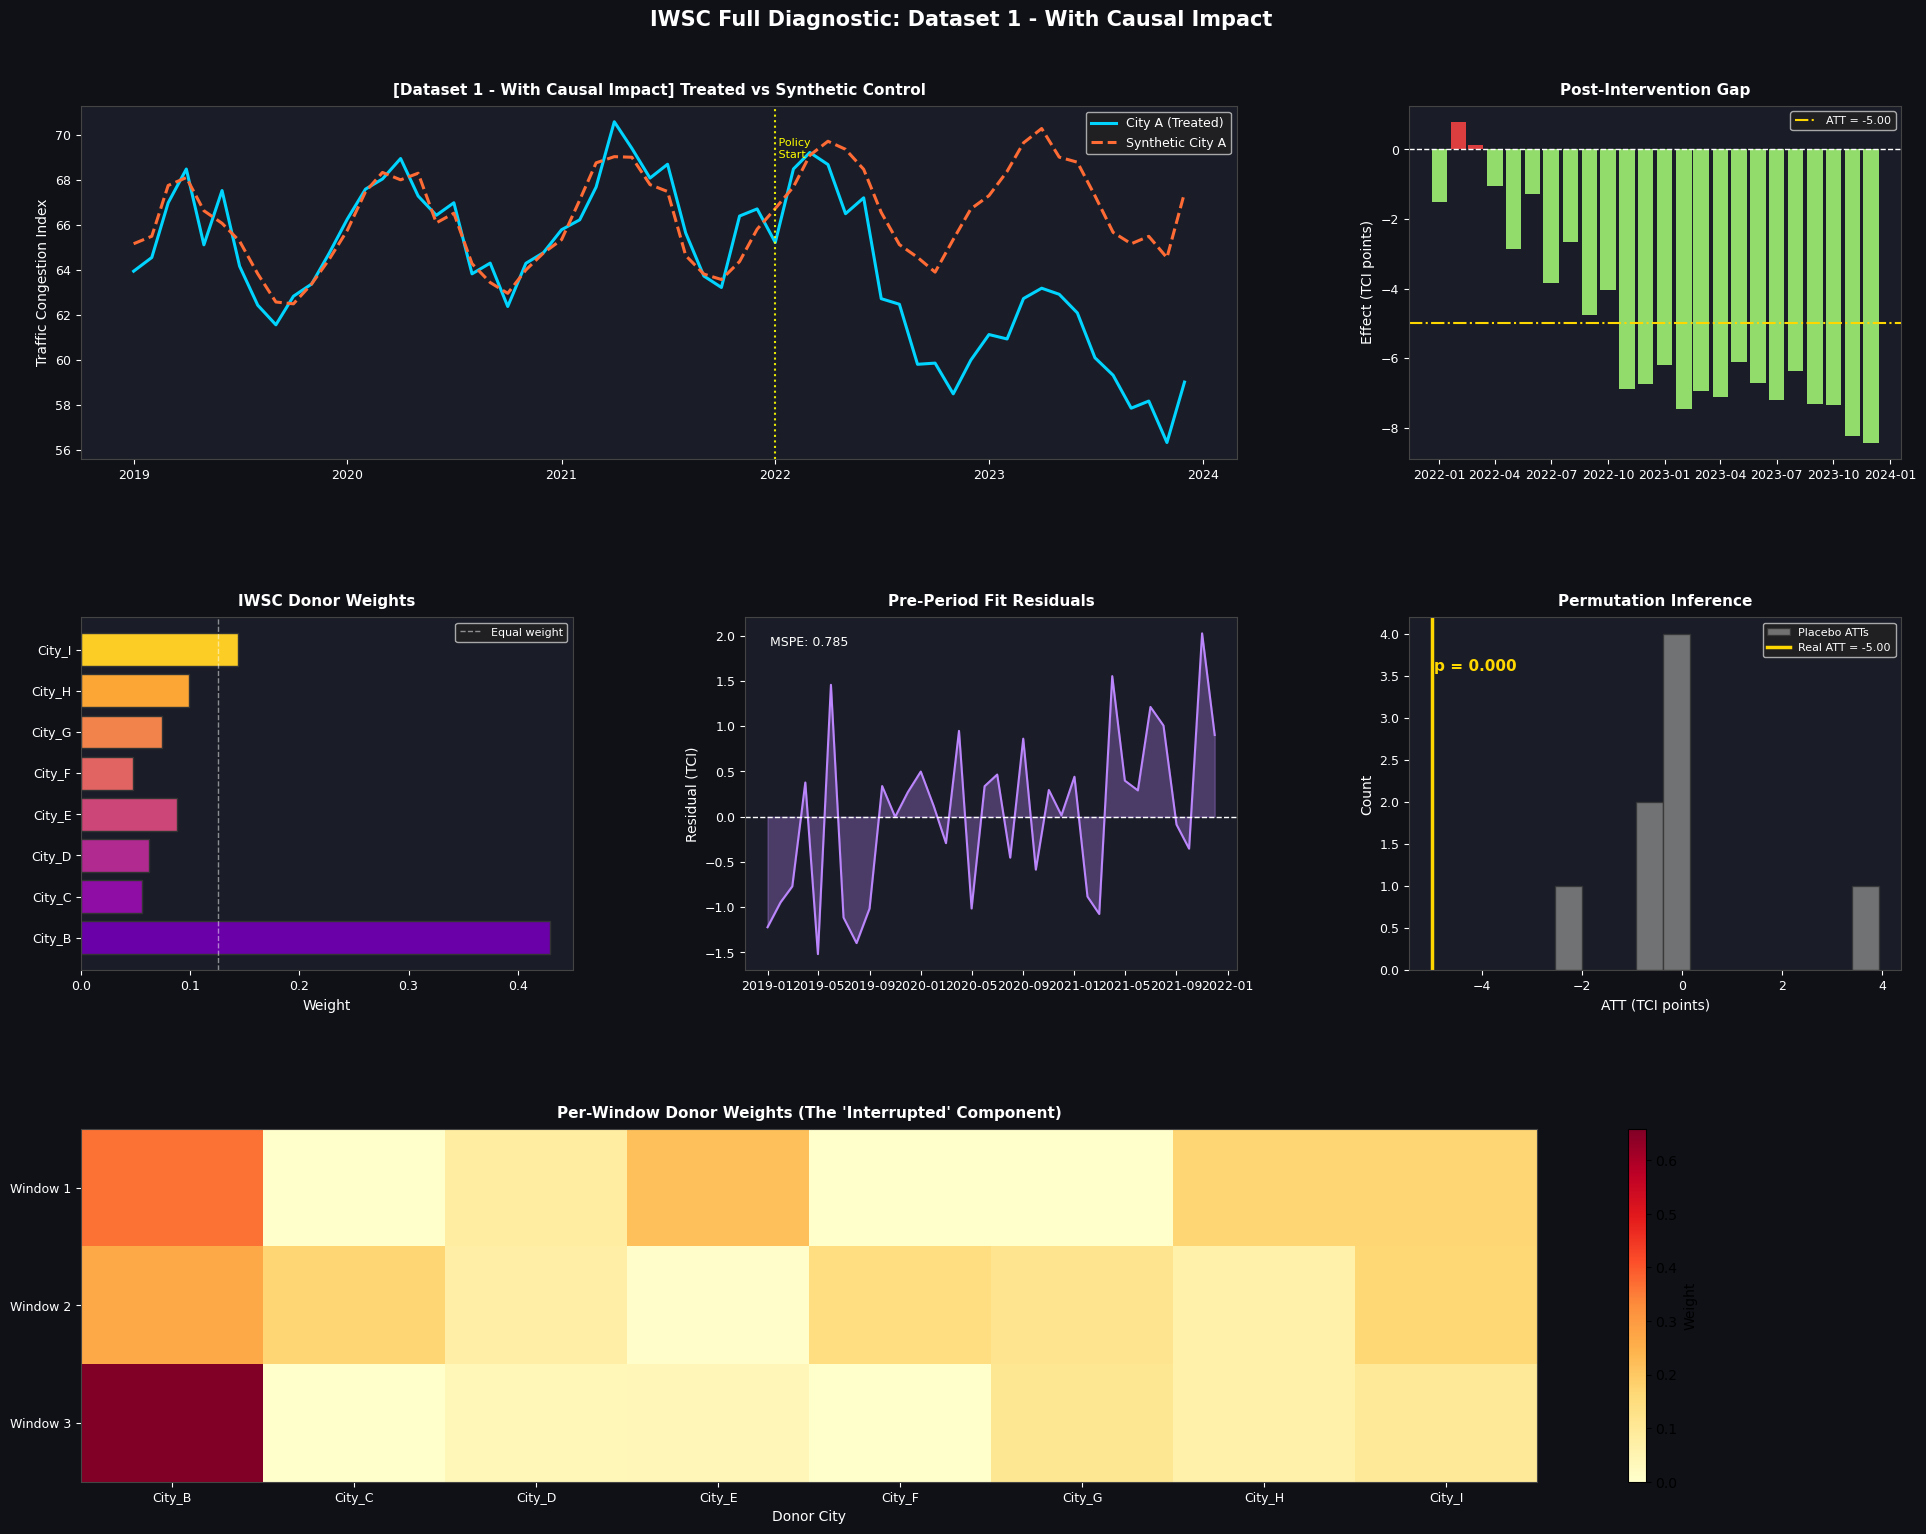

In [54]:
# -------------------------------------------------------------------------
# Step D: Run IWSC on Dataset 1 (real causal impact)
# -------------------------------------------------------------------------
results_impact = run_full_analysis(
    label="Dataset 1 - With Causal Impact",
    treated_series=treated_impact,
    donor_df=donor_df,
    time_index=time_index,
    intervention_date=INTERVENTION,
    n_windows=3
)
plot_full_results(results_impact, donor_df)

In [64]:
# PANEL 1 -- "Treated vs Synthetic Control" (main result plot)
#   Blue line = actual City A TCI
#   Orange dashed line = synthetic City A (what would have happened without policy)
#   Yellow dotted line = policy start date
#   WHAT TO LOOK FOR: In the pre-period (left of yellow line), the two lines
#   should be close together -- that means our synthetic is a good match.
#   In the post-period (right of yellow line), if blue drops below orange,
#   the policy reduced congestion. The bigger the gap, the stronger the effect.
#
# PANEL 2 -- "Post-Intervention Gap"
#   Each bar = (actual TCI) minus (synthetic TCI) for that month after policy
#   Green bars = actual is below synthetic = congestion went DOWN (good)
#   Red bars = actual is above synthetic = congestion went UP
#   Gold horizontal line = ATT (average of all the bars)
#   WHAT TO LOOK FOR: Consistently green bars with a clearly negative ATT
#   is strong evidence of a real reduction in congestion.
#
# PANEL 3 -- "IWSC Donor Weights"
#   Horizontal bars = how much weight each donor city received
#   A city with high weight = its trajectory looked most like City A pre-policy
#   Dashed white line = what equal weights would look like (1/8 each)
#   WHAT TO LOOK FOR: If most weight is on 1-2 cities, your synthetic is
#   really just those cities. That is fine as long as pre-period fit is good.
#
# PANEL 4 -- "Pre-Period Fit Residuals"
#   Purple line = (actual City A) minus (synthetic City A) for each pre-period month
#   Should hover around zero with no systematic trend
#   MSPE printed in top left = mean squared prediction error (lower = better fit)
#   WHAT TO LOOK FOR: If residuals trend upward or downward over time,
#   your synthetic is drifting away from City A even before the policy --
#   that is a red flag and the causal claim becomes unreliable.
#
# PANEL 5 -- "Permutation Inference" (HOW WE KNOW IF EFFECT IS STATISTICALLY SIGNIFICANT)
#   Gray histogram = ATT values from running IWSC on each donor as a fake treated city
#   These are called placebo ATTs -- what you'd get if there was NO real effect
#   Gold vertical line = City A's real ATT
#   p-value = fraction of placebos that got an ATT as extreme as City A's real ATT
#   WHAT TO LOOK FOR: If the gold line is far in the left tail and p < 0.10,
#   the effect is statistically unusual compared to random chance.
#   p < 0.10 is the standard threshold used in SC literature (not 0.05 like regression)
#   because with only ~8 donors the permutation distribution is coarse.
#
# PANEL 6 -- "Per-Window Weights Heatmap" (THE INTERRUPTED PART)
#   Rows = time windows in the pre-period (Window 1 = earliest, Window 3 = latest)
#   Columns = each donor city
#   Color intensity = how much weight that donor got in that window
#   WHAT TO LOOK FOR: If weights shift across windows (e.g., City B is dark in
#   Window 1 but light in Window 3), it means City B's relationship with City A
#   changed over time. IWSC handles this by averaging across windows.
#


  ANALYSIS: Dataset 2 - Null Case No Impact

Final IWSC Donor Weights:
  City_B: 0.3784
  City_C: 0.0560
  City_D: 0.1882
  City_E: 0.1525
  City_F: 0.0092
  City_G: 0.0254
  City_H: 0.1227
  City_I: 0.0676

Pre-period MSPE (fit quality, lower is better): 1.3314
Average Treatment Effect on Treated (ATT):      1.0311 TCI points

Running placebo tests (this applies IWSC to each donor as fake treated)...
Placebo ATTs range: [-2.53, 3.93]
Permutation p-value: 0.8750


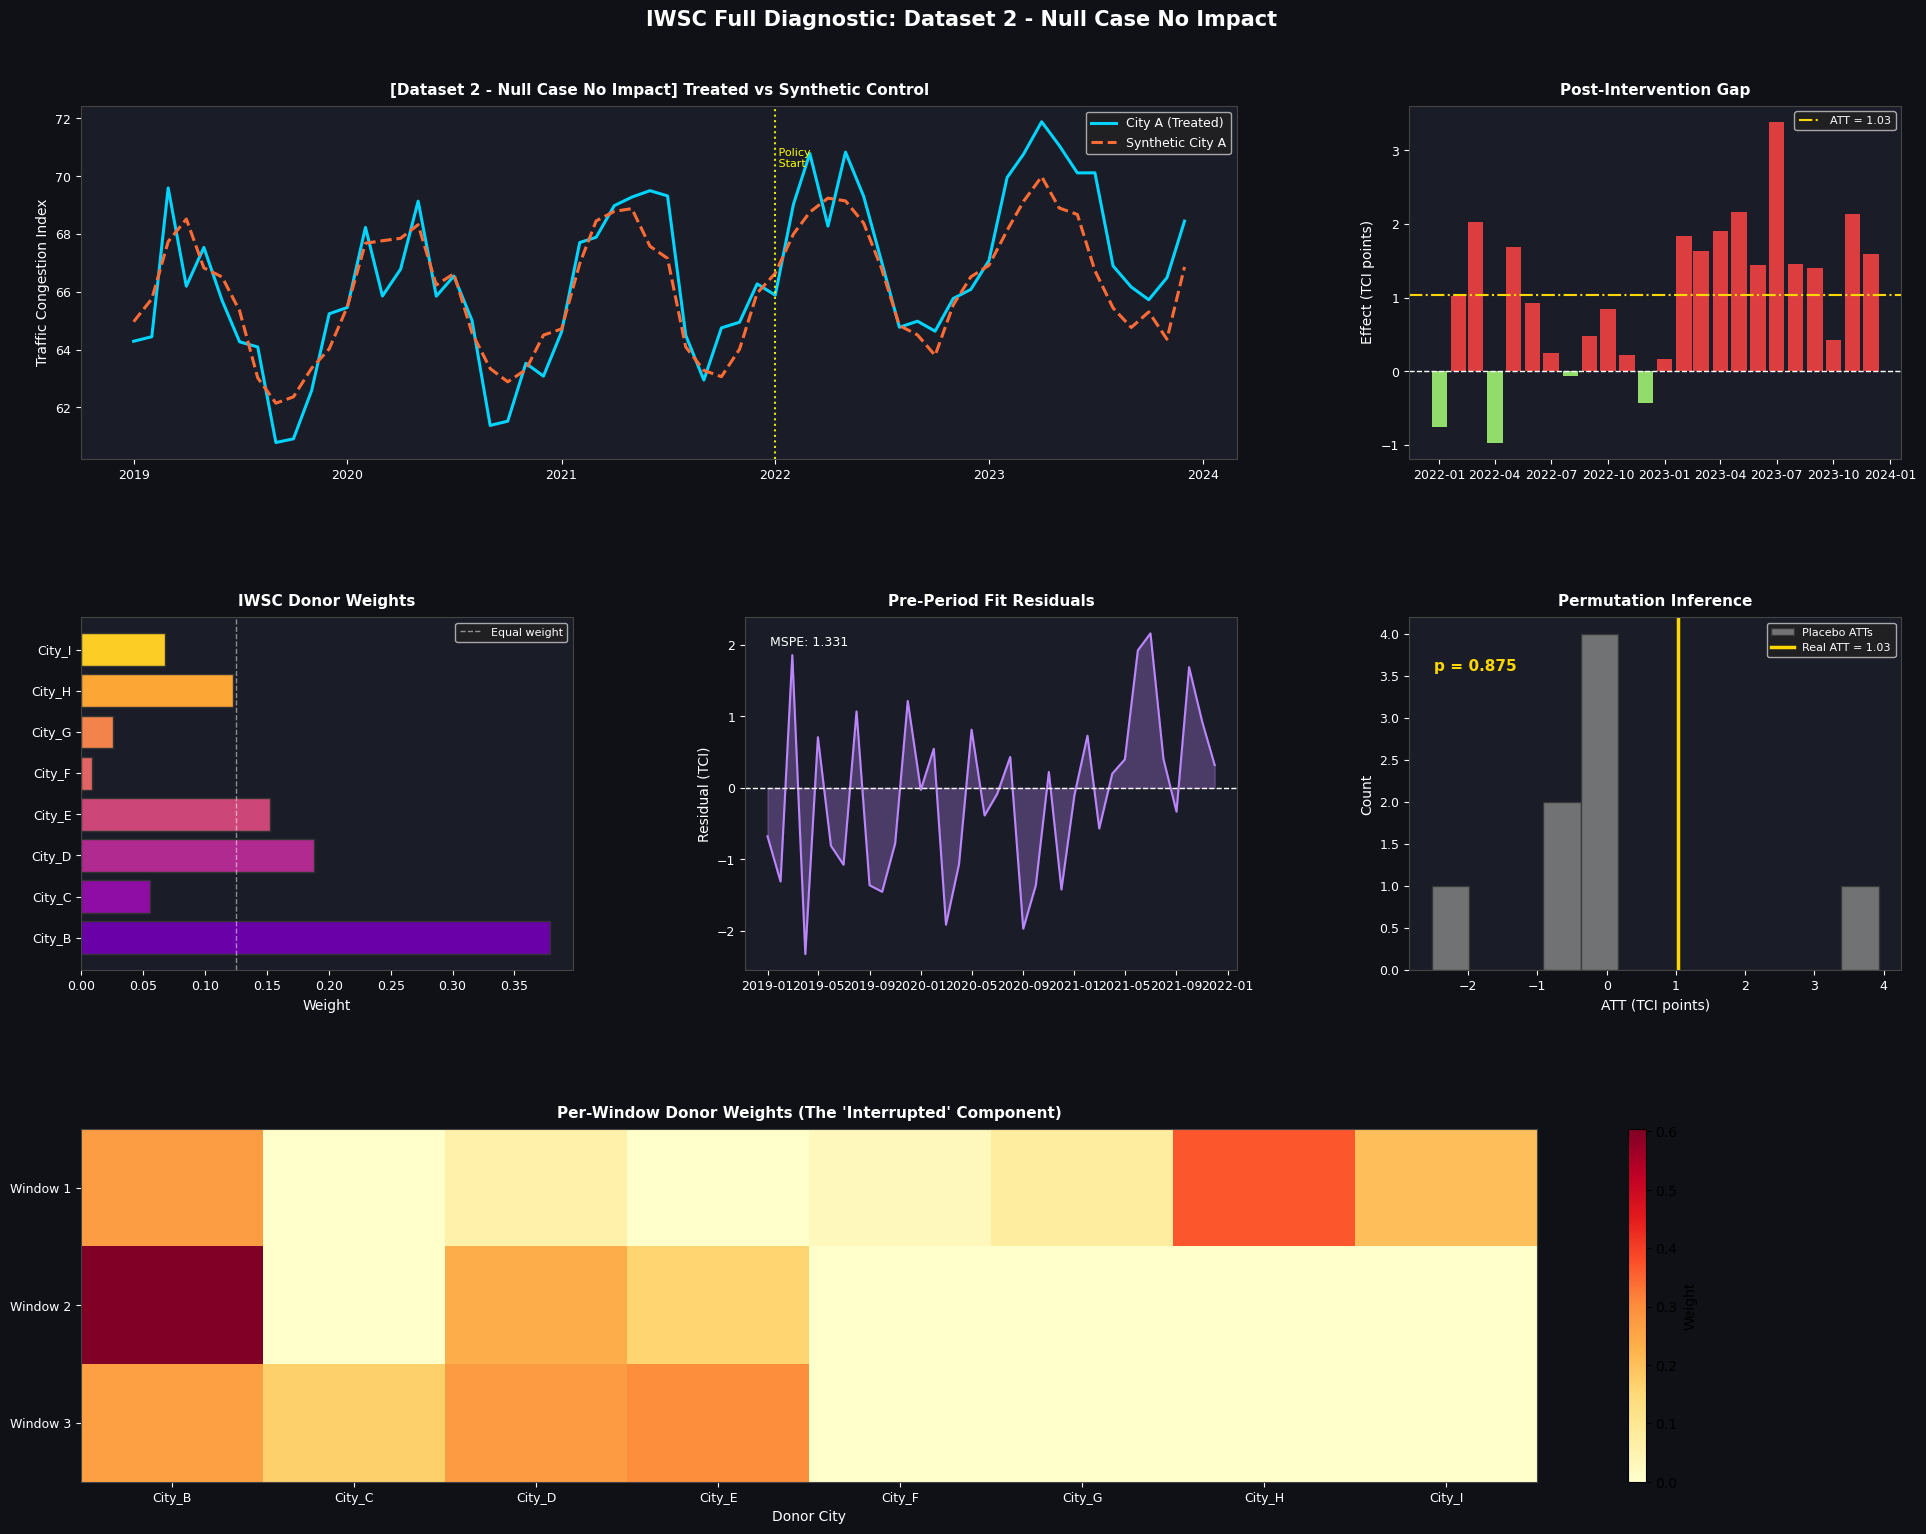

In [45]:
# -------------------------------------------------------------------------
# Step E: Run IWSC on Dataset 2 (null case)
# -------------------------------------------------------------------------
results_null = run_full_analysis(
    label="Dataset 2 - Null Case No Impact",
    treated_series=treated_null,
    donor_df=donor_df,
    time_index=time_index,
    intervention_date=INTERVENTION,
    n_windows=3
)
plot_full_results(results_null, donor_df)

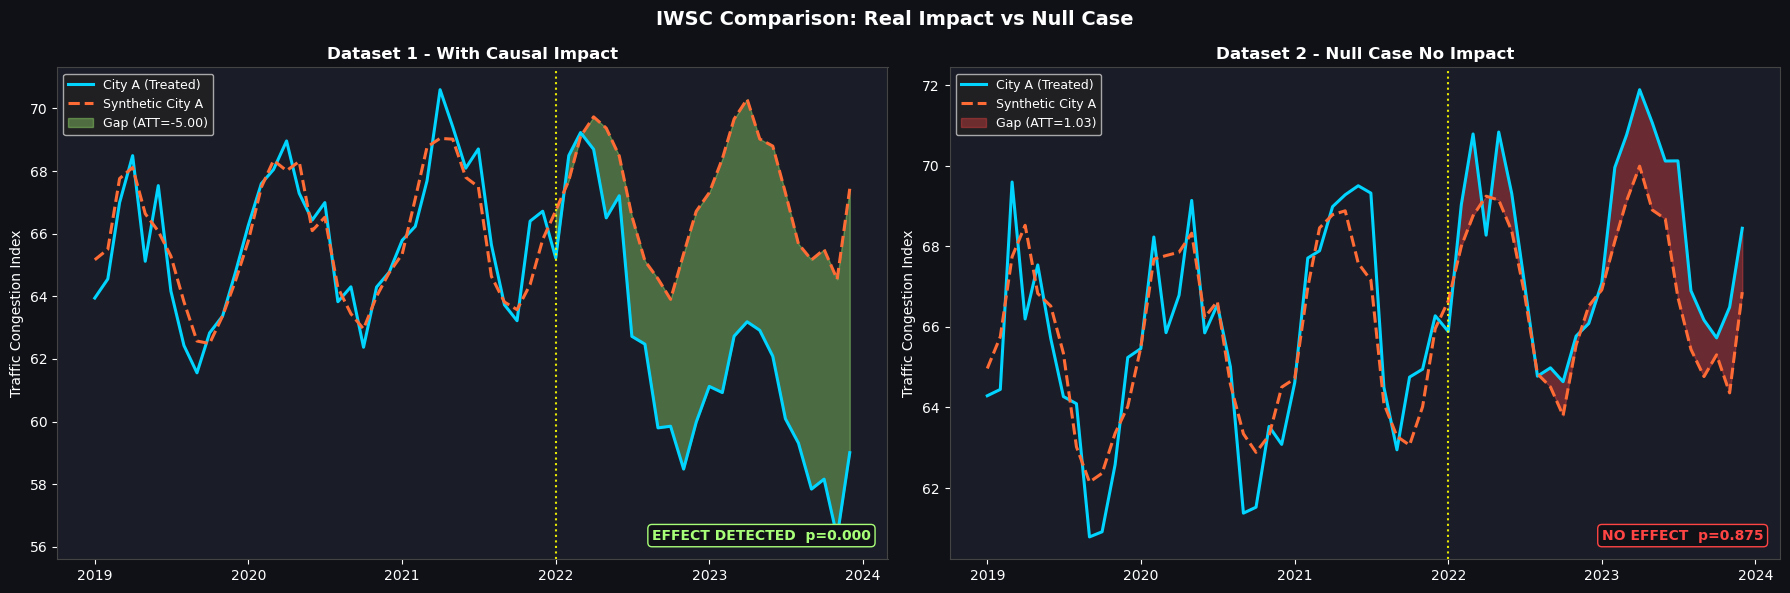

In [65]:
# -------------------------------------------------------------------------
# Step F: Side-by-side comparison chart
# -------------------------------------------------------------------------
plot_side_by_side_comparison(results_impact, results_null)

In [66]:
# -------------------------------------------------------------------------
# Step G: Final summary table
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
summary = pd.DataFrame({
    "Metric": [
        "Pre-period MSPE (fit quality)",
        "Average Treatment Effect (ATT)",
        "Permutation p-value",
        "Conclusion"
    ],
    "Dataset 1 (Real Impact)": [
        f"{results_impact['pre_mspe']:.3f}",
        f"{results_impact['att']:.3f} TCI pts",
        f"{results_impact['p_value']:.3f}",
        "EFFECT DETECTED" if results_impact['p_value'] < 0.1 else "No effect"
    ],
    "Dataset 2 (Null Case)": [
        f"{results_null['pre_mspe']:.3f}",
        f"{results_null['att']:.3f} TCI pts",
        f"{results_null['p_value']:.3f}",
        "EFFECT DETECTED" if results_null['p_value'] < 0.1 else "NO EFFECT (correct)"
    ]
})
print(summary.to_string(index=False))
print("\nKey Takeaway:")
print("  IWSC correctly identifies a significant effect in Dataset 1")
print("  and correctly finds no effect in Dataset 2 (null case).")
print("  Pre-period MSPE < 5 is considered a good synthetic control fit.")



  FINAL SUMMARY
                        Metric Dataset 1 (Real Impact) Dataset 2 (Null Case)
 Pre-period MSPE (fit quality)                   0.785                 1.331
Average Treatment Effect (ATT)          -5.002 TCI pts         1.031 TCI pts
           Permutation p-value                   0.000                 0.875
                    Conclusion         EFFECT DETECTED   NO EFFECT (correct)

Key Takeaway:
  IWSC correctly identifies a significant effect in Dataset 1
  and correctly finds no effect in Dataset 2 (null case).
  Pre-period MSPE < 5 is considered a good synthetic control fit.


In [70]:
# -------------------------------------------------------------------------
# QUESTION: HOW DO WE KNOW THE EFFECT IS CAUSAL?
# -------------------------------------------------------------------------
# Three things make this causal (not just correlational):
#
# 1. COUNTERFACTUAL LOGIC: The synthetic control is built to answer
#    "what would City A's TCI have been without the policy?" Any gap
#    between actual and synthetic post-intervention is attributed to the policy
#    -- not to City A just having a different trend from control cities.
#
# 2. PRE-PERIOD VALIDATION: If the synthetic tracks City A closely for 3 years
#    before the policy (low MSPE, flat residuals), we have strong evidence
#    that the synthetic is a valid counterfactual. It is essentially running
#    a retrospective "parallel trends" check -- but data-driven, not assumed.
#
# 3. NO SPILLOVER / NO ANTICIPATION ASSUMPTIONS: Causal interpretation requires
#    donor cities were NOT affected by City A's policy (no spillover), and
#    City A did not start changing behavior before the policy launched
#    (no anticipation effect). You check anticipation by looking at whether
#    the gap starts right at the intervention date, not before.
#
# Synthetic control does NOT give you causality for free. It is credible
# when: (a) pre-period fit is good, (b) the post-gap is large relative to
# placebo gaps, (c) the intervention date aligns with when the gap opens.

In [ ]:
# -------------------------------------------------------------------------
# QUESTION: HOW DO WE KNOW THE EFFECT IS STAT SIG?
# -------------------------------------------------------------------------
#Permutation Inference, explained from scratchForget statistics for a moment. 
#Here is the intuition:You observe that City A's TCI dropped 6 points below its synthetic after the policy. 
#Your question is: "Is a 6-point drop unusual, or do cities just randomly drift 6 points from their synthetics
#all the time for no reason?"To answer that, you run an experiment. 

#You pick City B, which had NO policy. You pretend City B is the treated city, 
#build a synthetic for it using all other donors, and measure how far City B drifted from its synthetic in the same post-period. 
#Call that drift City B's placebo ATT. Then you repeat this for City C, City D, all 8 donors.
#Now you have 8 placebo ATTs. 

#These represent the natural random drift between a city and its synthetic when absolutely nothing happened. 
#If City A's real ATT of -6 is more extreme than all 8 placebo ATTs, then a -6 drift basically never happens by chance. 
#That is your p-value: 0 out of 8 placebos were as extreme, so p = 0/8 = 0.
#If 2 out of 8 placebos had ATTs as extreme as City A's, p = 2/8 = 0.25, 
#meaning a drift that big happens 25% of the time by random chance, and you cannot claim the policy caused it.

In [69]:
# -------------------------------------------------------------------------
# QUESTION: HOW DO WE DETERMINE THE RUNTIME OF THE MEASUREMENT PERIOD?
# -------------------------------------------------------------------------
# There is no universal formula. You balance three things:
#
# PRE-PERIOD (before intervention):
#   - Needs to be long enough to fit a reliable synthetic control.
#     Rule of thumb: at least 2-3x longer than your post-period.
#     Here we use 36 months pre (Jan 2019 - Dec 2021).
#   - Too short: weights are unreliable, poor counterfactual.
#   - Too long: donor relationships may shift structurally (hence IWSC).
#
# POST-PERIOD (after intervention):
#   - Long enough to see the effect stabilize (not just launch noise).
#     Here 24 months (Jan 2022 - Dec 2023).
#   - Too short: may only capture early transient effects.
#   - Too long: more risk that unrelated external shocks affect donors or
#     treated city, contaminating the comparison.
#
# PRACTICAL CONSIDERATIONS:
#   - Effect onset: Does the policy take time to ramp up? (Scooter adoption
#     takes months to scale.) Your post-period must cover the ramp.
#   - External validity windows: Avoid periods with major confounders
#     (e.g., COVID lockdowns would destroy a transport study).
#   - Data availability: Monthly data needs fewer periods than weekly data.